Author: Krish

In [9]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### User input required
Put the data path on your system in the cell below

In [10]:
data_path = "CAR_-_EP_Flow_Activity_Queue__Agent_Names"

### User input ends

### Reading all filenames in the data folder

In [11]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


### Reading all data files
The code chunk below reads and appends all the CAR data files. The first two rows of each file are blank and thus ignored.

In [12]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

### Time datatype conversion
The code chunk below converts time from string to datetime datatype.

In [13]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [14]:
# Checking the datatype of all columns
df_main.dtypes

Contact Session ID                  object
EP Name                             object
Flow Name                           object
Activity Name                       object
Activity Start Timestamp    datetime64[ns]
Queue Name                          object
Agent Name                          object
Termination Reason                  object
dtype: object

In [15]:
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

### Cleaning Data

In [16]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous row within each Contact Session ID) ---

# Ensure timestamp is datetime (safe if it's already datetime64[ns])
df_filt['Activity Start Timestamp'] = pd.to_datetime(df_filt['Activity Start Timestamp'], errors='coerce')

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)

# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column

### Filtering 1: Sessions where Main Menu was reached and proceeded further

Reason: I do not want to take into account cases when the session ended before or at the Main Menu prompt since that will provide no insight in analyzing the paths taken beyond the Main Menu.

In [ ]:
# Initialize a list for qualifying Contact Session IDs
qualifying_sessions = []

# Loop over each Contact Session ID group
for contact_id, group in df_filt.groupby("Contact Session ID"):

    # Find first occurrence of MainMenu
    mainmenu_rows = group[group["Activity Name"] == "MainMenu"]
    if mainmenu_rows.empty:
        continue  # skip if there's no MainMenu
    
    first_mainmenu_time = mainmenu_rows["Activity Start Timestamp"].iloc[0] 

    # Rows after that MainMenu
    after_mainmenu = group[group["Activity Start Timestamp"] > first_mainmenu_time]

    # Keep Contact Session ID if any subsequent row has a non-null Activity Name
    if after_mainmenu["Activity Name"].notna().any():
        qualifying_sessions.append(contact_id)

# Filter df_filt to include only qualifying sessions
df_filt_filtered = df_filt[df_filt["Contact Session ID"].isin(qualifying_sessions)].copy()

In [44]:
num_qual = df_filt_filtered["Contact Session ID"].nunique() / df_filt["Contact Session ID"].nunique()
print(num_qual)

0.64955200811457


Approximately 65% of calls reach the Main Menu and go further down the call path.

### Filtering 2: Check if person hears all options

In [53]:
# Find the first instance of "MainMenu" for each Contact Session ID
first_mainmenu = (
    df_filt_filtered[df_filt_filtered["Activity Name"] == "MainMenu"]
    .sort_values(["Contact Session ID", "Activity Start Timestamp"])
    .groupby("Contact Session ID")
    .first()
    .reset_index()
)

# Split Contact Session IDs based on whether seconds_until_next > 52
greater_than_52_ids = first_mainmenu.loc[first_mainmenu["seconds_until_next"] > 52, "Contact Session ID"]
less_equal_52_ids   = first_mainmenu.loc[first_mainmenu["seconds_until_next"] <= 52, "Contact Session ID"]

# Create two new DataFrames
df_filt_full = df_filt_filtered[df_filt_filtered["Contact Session ID"].isin(greater_than_52_ids)].copy()
df_filt_skip = df_filt_filtered[df_filt_filtered["Contact Session ID"].isin(less_equal_52_ids)].copy()

In [54]:
num_full = df_filt_full["Contact Session ID"].nunique() / df_filt_filtered["Contact Session ID"].nunique()
print(num_full)

0.14072724568709102


In [63]:
def classify_mainmenu_sessions(df):
    # Keep only relevant columns
    df = df.copy()
    
    # Initialize lists to store Contact Session IDs
    single_ids = []
    multiple_ids = []

    # Loop through each session
    for session_id, group in df.groupby("Contact Session ID"):
        mainmenu_mask = group["Activity Name"].eq("MainMenu")
        mainmenu_indices = mainmenu_mask[mainmenu_mask].index

        if len(mainmenu_indices) <= 1:
            # Only one MainMenu → single
            single_ids.append(session_id)
        else:
            # Check for consecutive sequences
            non_consecutive_groups = (mainmenu_indices.to_series().diff() != 1).cumsum()
            num_clusters = non_consecutive_groups.nunique()
            
            if num_clusters > 1:
                multiple_ids.append(session_id)
            else:
                single_ids.append(session_id)
    
    return single_ids, multiple_ids


# ---- For df_filt_full ----
single_mainmenu_ids_full, multiple_mainmenu_ids_full = classify_mainmenu_sessions(df_filt_full)

df_filt_full_single   = df_filt_full[df_filt_full["Contact Session ID"].isin(single_mainmenu_ids_full)].copy()
df_filt_full_multiple = df_filt_full[df_filt_full["Contact Session ID"].isin(multiple_mainmenu_ids_full)].copy()


# ---- For df_filt_skip ----
single_mainmenu_ids_skip, multiple_mainmenu_ids_skip = classify_mainmenu_sessions(df_filt_skip)

df_filt_skip_single   = df_filt_skip[df_filt_skip["Contact Session ID"].isin(single_mainmenu_ids_skip)].copy()
df_filt_skip_multiple = df_filt_skip[df_filt_skip["Contact Session ID"].isin(multiple_mainmenu_ids_skip)].copy()


In [64]:
num_full_single = df_filt_full_single["Contact Session ID"].nunique() / df_filt_full["Contact Session ID"].nunique()
print(num_full_single)

num_skip_single = df_filt_skip_single["Contact Session ID"].nunique() / df_filt_skip["Contact Session ID"].nunique()
print(num_skip_single)

0.662703654777631
0.9405766373876797


### Visualization of Main Menu instances per call session

In [45]:
# Count number of MainMenu per Contact Session ID
mainmenu_counts = (
    df_filt_filtered[df_filt_filtered["Activity Name"] == "MainMenu"]
    .groupby("Contact Session ID")
    .size()
)

# Convert to DataFrame showing frequency of each count
mainmenu_counts_df = mainmenu_counts.value_counts().sort_index().reset_index()
mainmenu_counts_df.columns = ["MainMenu_count", "Num_Contact_Sessions"]

print(mainmenu_counts_df)

   MainMenu_count  Num_Contact_Sessions
0               1                144171
1               2                 14581
2               3                  2208
3               4                   312
4               5                    69
5               6                    19
6               7                     8
7               8                     5
8               9                     2
9              48                     1


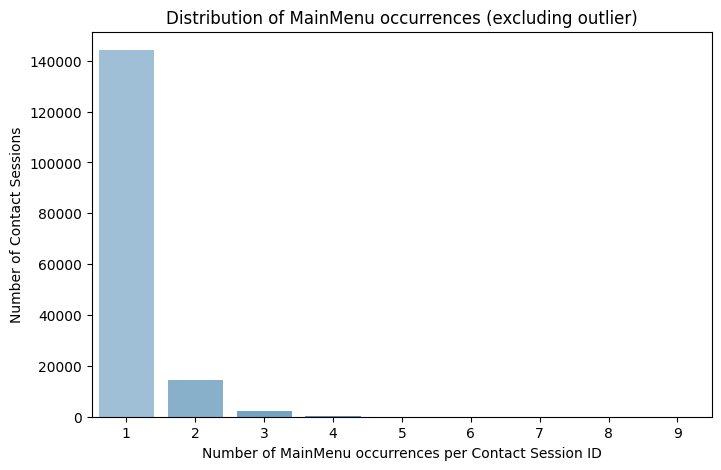

In [ ]:
# Filter out the outlier (MainMenu_count == 48)
mainmenu_counts_df_filtered = mainmenu_counts_df[mainmenu_counts_df["MainMenu_count"] != 48]

# Plot the bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x="MainMenu_count", 
    y="Num_Contact_Sessions", 
    data=mainmenu_counts_df_filtered, 
    palette="Blues_d"
)
plt.xlabel("Number of MainMenu occurrences per Contact Session ID")
plt.ylabel("Number of Contact Sessions")
plt.title("Distribution of MainMenu occurrences (excluding outlier)")
plt.show()

In [48]:
# Total number of Contact Sessions
total_sessions = mainmenu_counts_df["Num_Contact_Sessions"].sum()

# Number of sessions with 1 MainMenu_count
sessions_with_1 = mainmenu_counts_df.loc[mainmenu_counts_df["MainMenu_count"] == 1, "Num_Contact_Sessions"].iloc[0]

# Calculate percentage
percentage_1 = (sessions_with_1 / total_sessions) * 100

print(f"Percentage of contact sessions with only 1 MainMenu Encounter: {percentage_1:.2f}%")

Percentage of contact sessions with only 1 MainMenu Encounter: 89.34%


### Filtering 2: Sessions where there were multiple Main Menu encounters

In [49]:
# Find Contact Session IDs with more than one MainMenu
multiple_mainmenu_ids = (
    df_filt_filtered[df_filt_filtered["Activity Name"] == "MainMenu"]
    .groupby("Contact Session ID")
    .size()
    .loc[lambda x: x > 1]
    .index
)

# Filter the main DataFrame to keep only those IDs
df_filt_multiple_mainmenu = df_filt_filtered[
    df_filt_filtered["Contact Session ID"].isin(multiple_mainmenu_ids)
].copy()

In [ ]:
# Initialize lists to collect session IDs
only_consecutive_ids = []
rest_ids = []

# Loop over each Contact Session ID group
for contact_id, group in df_filt_multiple_mainmenu.groupby("Contact Session ID"):
    group = group.sort_values("Activity Start Timestamp")
    mainmenu_rows = group["Activity Name"] == "MainMenu"
    
    # Shift to compare previous row
    prev_activity = group["Activity Name"].shift()
    consecutive = (mainmenu_rows & (prev_activity == "MainMenu"))
    
    has_consecutive = consecutive.any()
    num_mainmenu = mainmenu_rows.sum()
    
    # If all MainMenu occurrences are part of consecutive pairs, it's "only consecutive"
    if has_consecutive and num_mainmenu == consecutive.sum() + 1:
        only_consecutive_ids.append(contact_id)
    else:
        rest_ids.append(contact_id)

df_filt_only_consecutive = df_filt_multiple_mainmenu[
    df_filt_multiple_mainmenu["Contact Session ID"].isin(only_consecutive_ids)
].copy()

df_filt_rest = df_filt_multiple_mainmenu[
    df_filt_multiple_mainmenu["Contact Session ID"].isin(rest_ids)
].copy()

In [51]:
num_repeat = df_filt_only_consecutive["Contact Session ID"].nunique() / df_filt_multiple_mainmenu["Contact Session ID"].nunique()
print(num_repeat)

0.504388259226969


Approximately 50% of call sessions with multiple Main Menu Prompt counts are instances of callers simply repeating the Main Menu Prompt without coming back at a later stage of the call.

### Filtering 3: Sessions that ended at a queue (Successful calls)

In [ ]:
# Find session IDs that meet either condition
valid_sessions = df_filt_filtered.loc[
    (df_filt_filtered["Activity Name"] == "ClosedQueueMenu") |
    (df_filt_filtered["Queue Name"].notna()),
    "Contact Session ID"
].unique()

# Keep only rows belonging to those valid sessions
df_success = df_filt_filtered[df_filt_filtered["Contact Session ID"].isin(valid_sessions)]

In [62]:
num_success = df_success["Contact Session ID"].nunique() / df_filt_filtered["Contact Session ID"].nunique()
print(num_repeat)

0.504388259226969


### Sub Menu Analysis

In [70]:
# Count how many times "MainMenu" appears per Contact Session
mainmenu_counts = (
    df_filt_filtered[df_filt_filtered["Activity Name"] == "MainMenu"]
    .groupby("Contact Session ID")
    .size()
)

# Get the IDs where it appears more than once
multiple_mainmenu_ids = mainmenu_counts[mainmenu_counts > 1].index

# Filter the original DataFrame
df_multiple_mainmenu = df_filt_filtered[df_filt_filtered["Contact Session ID"].isin(multiple_mainmenu_ids)]

In [71]:
# Find previous activity within each session
df_multiple_mainmenu["Prev Activity"] = df_multiple_mainmenu.groupby("Contact Session ID")["Activity Name"].shift(1)

# Keep only rows where Activity Name == "MainMenu"
df_mainmenu = df_multiple_mainmenu[df_multiple_mainmenu["Activity Name"] == "MainMenu"].copy()

# Within each session, skip the *first* MainMenu (keep 2nd, 3rd, ...)
df_mainmenu["MainMenu_Order"] = df_mainmenu.groupby("Contact Session ID").cumcount() + 1
df_after_first = df_mainmenu[df_mainmenu["MainMenu_Order"] > 1]

# Count how many times each previous activity leads into a subsequent MainMenu
prev_counts = df_after_first["Prev Activity"].value_counts().reset_index()
prev_counts.columns = ["Previous Activity", "Count"]

print(prev_counts)


                Previous Activity  Count
0                        MainMenu  10652
1  HelpWithLegalorOtherReasonMenu   3688
2                 AppointmentMenu   2588
3             AddressFaxHoursMenu   1342
4       ComplimentOrComplaintMenu    866
5                      LegalMenu2    418


In [ ]:
# Target activity names
target_activities = [
    "HelpWithLegalorOtherReasonMenu",
    "AppointmentMenu",
    "AddressFaxHoursMenu",
    "ComplimentOrComplaintMenu",
    "LegalMenu2"
]

# Count how many *unique contact sessions* reached each activity
activity_session_counts = (
    df_filt_filtered[df_filt_filtered["Activity Name"].isin(target_activities)]
    .groupby("Activity Name")["Contact Session ID"]
    .nunique()
    .reset_index(name="Session Count")
)

print(activity_session_counts)

                    Activity Name  Session Count
0             AddressFaxHoursMenu           1632
1                 AppointmentMenu          13190
2       ComplimentOrComplaintMenu           1154
3  HelpWithLegalorOtherReasonMenu          11989
4                      LegalMenu2          85109
